In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '1'  # Replace digit with number of desired GPU
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
# Basic Library Imports
import jax
import jax.numpy as jnp
from jax import random
from jax import vmap, jit

from flax import linen as nn
from flax.core import FrozenDict
import optax

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
from tqdm import tqdm, trange
import sys
import pickle
from datetime import datetime

In [ ]:
%reload_ext autoreload
%autoreload 2
sys.path.append('../..')
from jaxmix.archs import MLP, MDN, Ensemble, RPNEnsemble
from jaxmix.trainers import MDNTrainer, ConditionalFlowMatchingTrainer
from jaxmix.utils import split_data
from jaxmix.data_loaders import BatchedDataset, FlowMatchingDataset
from utils import (plot_bifurcation_diagram, plot_mixture_outputs_1d, 
                   plot_ensemble_samples_1d, plot_cfm_ensemble_samples_1d, 
                   generate_saddle_node_data)

In [4]:
# Global experiment configuration
MASTER_KEY = random.PRNGKey(42)
TIME_STEPS = 20
FINAL_TIME = 5.0
DATASET_SIZES = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
N_TEST = 2000 

# Model architecture
OUT_DIM = TIME_STEPS
NUM_MIXTURES = 15
ENSEMBLE_SIZE = 12

# Training configuration
NUM_ITERS_MDN = 50_000
NUM_ITERS_CFM = 50_000
BATCH_SIZE = 128

In [5]:
def create_mdn_architecture():
    base_arch = MLP(features=[256, 256, 256, 256, 256])
    backbone_arch = Ensemble(base_arch, ENSEMBLE_SIZE)
    return MDN(num_mixtures=NUM_MIXTURES, num_output_dims=OUT_DIM,
               backbone=backbone_arch, ensemble_size=ENSEMBLE_SIZE)

def create_cfm_architecture():
    cfm_base_arch = MLP(features=[256, 256, 256, 256, 256, OUT_DIM])
    return Ensemble(cfm_base_arch, ENSEMBLE_SIZE)

def create_optimizer():
    num_linear_steps = 2000
    peak_lr = 5e-4
    lr = optax.join_schedules(
        schedules=[
            optax.linear_schedule(init_value=0.0, end_value=peak_lr, transition_steps=num_linear_steps),
            optax.exponential_decay(init_value=peak_lr, transition_steps=2_000, decay_rate=0.9),
        ],
        boundaries=[num_linear_steps]
    )
    return optax.chain(
        optax.adaptive_grad_clip(0.1),
        optax.adamw(learning_rate=lr, weight_decay=1e-5)
    )

## Part 1: Generate Fixed Test Dataset

We use a large, fixed test set to evaluate all models consistently.

Generated 13000 trajectories with dt=0.001000, total_time_steps=5001, subsampled_steps=20
Test set: (2000, 1), Training pool: (11000, 1)


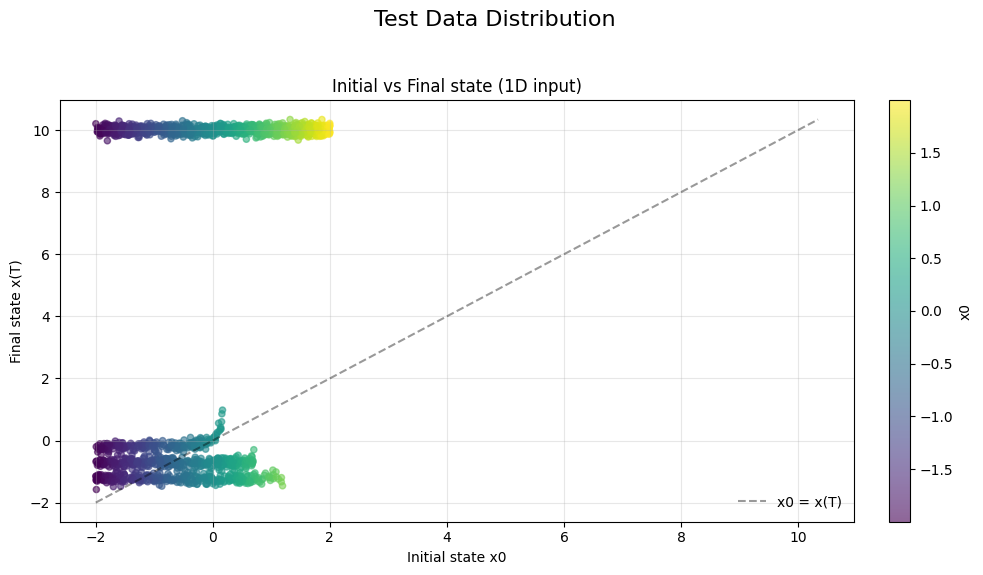

In [6]:
key = MASTER_KEY
key, subkey = random.split(key)

max_train_size = max(DATASET_SIZES)
total_samples = max_train_size + N_TEST + 1000

all_inputs, all_outputs = generate_saddle_node_data(
    n_samples=total_samples,
    time_steps=TIME_STEPS,
    key=subkey,
    dt=0.001,
    final_time=FINAL_TIME,
    x0_min=-2.0, 
    x0_max=2.0,
    noise_factor=0.0,         
    observation_noise=0.1,
    clip_threshold=10.0
)

# Create fixed test set
key, subkey = random.split(key)
indices = random.permutation(subkey, jnp.arange(total_samples))

test_indices = indices[:N_TEST]
train_pool_indices = indices[N_TEST:]

test_inputs = all_inputs[test_indices]
test_outputs = all_outputs[test_indices]
test_weights = jnp.ones(N_TEST)

train_pool_inputs = all_inputs[train_pool_indices]
train_pool_outputs = all_outputs[train_pool_indices]

print(f"Test set: {test_inputs.shape}, Training pool: {train_pool_inputs.shape}")
plot_bifurcation_diagram(test_inputs, test_outputs, "Test Data Distribution")

## Part 2: Sample Efficiency Study

Train MDN and CFM on varying dataset sizes and compare test NLL.

In [7]:
def train_and_evaluate_mdn(train_inputs, train_outputs, test_inputs, test_outputs, 
                           key, n_iters=NUM_ITERS_MDN):
    """Train MDN and return per-ensemble-member test NLLs."""
    train_weights = jnp.ones(len(train_inputs))
    train_data = (train_inputs, train_outputs, train_weights)
    
    MDN_arch = create_mdn_architecture()
    optimizer = create_optimizer()
    
    key, subkey = random.split(key)
    model = MDNTrainer(
        MDN_arch, train_data, key=subkey, optimizer=optimizer,
        masked_param_names='arch_prior', normalize_inputs=True, normalize_outputs=True
    )
    
    key, subkey = random.split(key)
    batch_size = min(BATCH_SIZE, len(train_inputs))
    train_loader = BatchedDataset(train_data, subkey, batch_size=batch_size)
    model.train(train_loader, nIter=n_iters)
    
    pred = model.apply(model.params, test_inputs)
    nll_per_element = model.per_element_loss(pred, test_outputs)  # shape: (ensemble_size, batch_size, 1)
    
    # Compute median NLL for each ensemble member independently
    ensemble_nlls = jnp.median(nll_per_element.squeeze(-1), axis=1)  # shape: (ensemble_size,)
    
    return ensemble_nlls, model


def train_and_evaluate_cfm(train_inputs, train_outputs, test_inputs, test_outputs, 
                           key, n_iters=NUM_ITERS_CFM, num_euler_steps=200):
    """Train CFM and return per-ensemble-member test NLLs."""
    train_weights = jnp.ones(len(train_inputs))
    train_data = (train_inputs, train_outputs, train_weights)
    
    cfm_arch = create_cfm_architecture()
    optimizer = create_optimizer()
    
    key, subkey = random.split(key)
    data_loader = FlowMatchingDataset(train_data, subkey, batch_size=None, sigma=0.0)
    init_batch = next(iter(data_loader))
    
    key, subkey = random.split(key)
    model = ConditionalFlowMatchingTrainer(
        cfm_arch, init_batch, key=subkey, optimizer=optimizer,
        normalize_inputs=True, normalize_outputs=True, ensemble_size=ENSEMBLE_SIZE
    )
    
    key, subkey = random.split(key)
    batch_size = min(BATCH_SIZE, len(train_inputs))
    train_loader = FlowMatchingDataset(train_data, subkey, batch_size=batch_size, sigma=0.0)
    model.train(train_loader, nIter=n_iters)
    
    tiled_test_inputs = jnp.tile(test_inputs, (ENSEMBLE_SIZE, 1, 1))
    tiled_test_outputs = jnp.tile(test_outputs, (ENSEMBLE_SIZE, 1, 1))
    
    nll_per_element = model.compute_nll(
        model.params, tiled_test_inputs, tiled_test_outputs,
        num_steps=num_euler_steps, apply_kwargs=FrozenDict({'tile_inputs': False})
    )  # shape: (ensemble_size, batch_size)
    
    # Compute median NLL for each ensemble member independently
    ensemble_nlls = jnp.median(nll_per_element, axis=1)  # shape: (ensemble_size,)
    
    return ensemble_nlls, model

In [8]:
results = {
    'dataset_sizes': DATASET_SIZES,
    'ensemble_size': ENSEMBLE_SIZE,
    'mdn_nlls': {n: [] for n in DATASET_SIZES},
    'cfm_nlls': {n: [] for n in DATASET_SIZES},
}

key = MASTER_KEY

for n_train in DATASET_SIZES:
    print(f"\n{'='*60}\nTraining with N = {n_train} samples\n{'='*60}")
    
    # Sample training data once per dataset size
    key, subkey = random.split(key)
    train_idx = random.choice(subkey, jnp.arange(len(train_pool_inputs)), 
                              shape=(n_train,), replace=False)
    train_inputs = train_pool_inputs[train_idx]
    train_outputs = train_pool_outputs[train_idx]
    
    key, subkey = random.split(key)
    try:
        mdn_ensemble_nlls, _ = train_and_evaluate_mdn(
            train_inputs, train_outputs, test_inputs, test_outputs, subkey
        )
        results['mdn_nlls'][n_train] = np.array(mdn_ensemble_nlls)
        print(f"  MDN ensemble NLLs: {mdn_ensemble_nlls}")
    except Exception as e:
        print(f"  MDN training failed: {e}")
        results['mdn_nlls'][n_train] = np.full(ENSEMBLE_SIZE, np.nan)
    
    key, subkey = random.split(key)
    try:
        cfm_ensemble_nlls, _ = train_and_evaluate_cfm(
            train_inputs, train_outputs, test_inputs, test_outputs, subkey
        )
        results['cfm_nlls'][n_train] = np.array(cfm_ensemble_nlls)
        print(f"  CFM ensemble NLLs: {cfm_ensemble_nlls}")
    except Exception as e:
        print(f"  CFM training failed: {e}")
        results['cfm_nlls'][n_train] = np.full(ENSEMBLE_SIZE, np.nan)
    
    # Print summary for this dataset size
    mdn_nlls = results['mdn_nlls'][n_train]
    cfm_nlls = results['cfm_nlls'][n_train]
    print(f"\n  Summary N={n_train} (across {ENSEMBLE_SIZE} ensemble members):")
    print(f"    MDN: {np.nanmean(mdn_nlls):.3f} +/- {np.nanstd(mdn_nlls):.3f}")
    print(f"    CFM: {np.nanmean(cfm_nlls):.3f} +/- {np.nanstd(cfm_nlls):.3f}")

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_file = f'saved_plots/efficiency_results_{timestamp}.pkl'
os.makedirs('saved_plots', exist_ok=True)
with open(results_file, 'wb') as f:
    pickle.dump(results, f)
print(f"\n\nResults saved to {results_file}")


Training with N = 50 samples


  6%|▌         | 2922/50000 [00:09<00:38, 1230.14it/s, loss=-42.318077, grad_norm=294.81146]

100%|██████████| 50000/50000 [00:46<00:00, 1077.67it/s, loss=-77.36184, grad_norm=3255.2969]  


  MDN ensemble NLLs: [93.449295 80.59457  80.083725 80.94339  78.571495 77.73956  79.31775
 88.786545 87.055145 92.44719  93.876045 92.05616 ]


Computing NLL: 100%|██████████| 200/200 [00:38<00:00,  5.16it/s]


...

  CFM ensemble NLLs: [[-13.820799 ]
 [-13.87342  ]
 [-13.8475065]
 [-13.853547 ]
 [-13.915046 ]
 [-13.963545 ]
 [-13.977002 ]
 [-14.023975 ]
 [-13.951374 ]
 [-13.839684 ]
 [-13.97806  ]
 [-13.851525 ]]

  Summary N=5000 (across 12 ensemble members):
    MDN: -13.232 +/- 0.739
    CFM: -13.908 +/- 0.065

Training with N = 10000 samples


100%|██████████| 50000/50000 [00:46<00:00, 1068.84it/s, loss=-43.01113, grad_norm=66.98699]   


  MDN ensemble NLLs: [-13.877813 -13.908414 -14.1545   -13.903613 -13.888517 -12.027189
 -13.942537 -12.777133 -13.867699 -11.899729 -14.176147 -14.042374]


Computing NLL: 100%|██████████| 200/200 [00:36<00:00,  5.44it/s]


  CFM ensemble NLLs: [[-14.019369 ]
 [-14.0722885]
 [-13.932379 ]
 [-13.899479 ]
 [-13.962194 ]
 [-13.898042 ]
 [-13.798463 ]
 [-13.929642 ]
 [-14.054824 ]
 [-14.071193 ]
 [-14.028742 ]
 [-14.039135 ]]

  Summary N=10000 (across 12 ensemble members):
    MDN: -13.539 +/- 0.784
    CFM: -13.975 +/- 0.082


Results saved to saved_plots/efficiency_results_20260128_134550.pkl


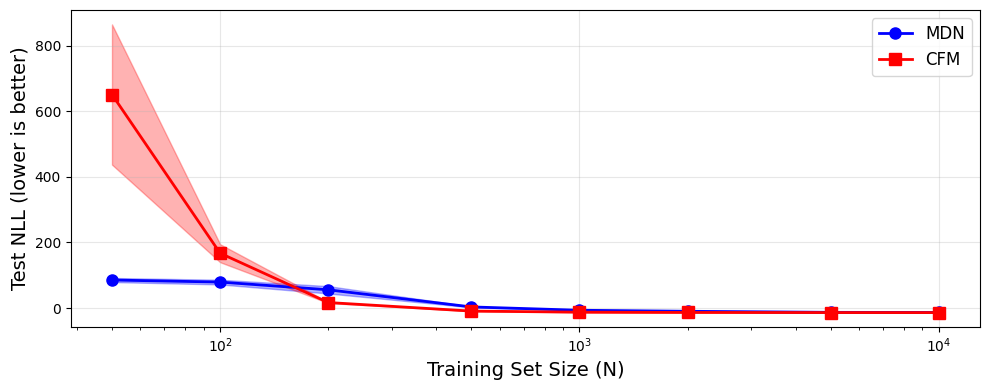

In [9]:
def plot_efficiency_comparison(results):
    """Plot NLL vs dataset size comparison (like Figure 3 in the paper)."""
    fig, ax = plt.subplots(figsize=(10, 4))  # Reduced height to compress y-axis
    
    dataset_sizes = results['dataset_sizes']
    # Updated to use new results format with per-ensemble-member NLLs
    mdn_means = [np.nanmean(results['mdn_nlls'][n]) for n in dataset_sizes]
    mdn_stds = [np.nanstd(results['mdn_nlls'][n]) for n in dataset_sizes]
    cfm_means = [np.nanmean(results['cfm_nlls'][n]) for n in dataset_sizes]
    cfm_stds = [np.nanstd(results['cfm_nlls'][n]) for n in dataset_sizes]
    
    ax.plot(dataset_sizes, mdn_means, 'o-', color='blue', label='MDN', linewidth=2, markersize=8)
    ax.fill_between(dataset_sizes, 
                    np.array(mdn_means) - np.array(mdn_stds),
                    np.array(mdn_means) + np.array(mdn_stds), alpha=0.3, color='blue')
    
    ax.plot(dataset_sizes, cfm_means, 's-', color='red', label='CFM', linewidth=2, markersize=8)
    ax.fill_between(dataset_sizes, 
                    np.array(cfm_means) - np.array(cfm_stds),
                    np.array(cfm_means) + np.array(cfm_stds), alpha=0.3, color='red')
    
    ax.set_xscale('log')
    ax.set_xlabel('Training Set Size (N)', fontsize=14)
    ax.set_ylabel('Test NLL (lower is better)', fontsize=14)
    # ax.set_title('Sample Efficiency: Saddle-Node Bifurcation', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('saved_plots/efficiency_comparison.pdf', dpi=150, bbox_inches='tight')
    plt.show()

plot_efficiency_comparison(results)